Gym environment implementations (CartPole )

In [ ]:
!pip install gymnasium[classic-control]
!pip install pygame

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.3 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
from IPython.display import clear_output
import time

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

print("Environment Created Successfully!")

Environment Created Successfully!


In [ ]:
print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)

Action Space: Discrete(2)
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [ ]:
state, info = env.reset()

print("Initial State:")
print(state)

Initial State:
[0.02495215 0.04852055 0.04268868 0.01627772]


In [ ]:
for step in range(10):

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"\nStep {step+1}")
    print("Action Taken:", action)
    print("Next State:", next_state)
    print("Reward:", reward)

    if terminated or truncated:
        print("Episode Finished!")
        break


Step 1
Action Taken: 0
Next State: [ 0.02592256 -0.14718679  0.04301423  0.32211795]
Reward: 1.0

Step 2
Action Taken: 1
Next State: [0.02297883 0.04729708 0.04945659 0.04330427]
Reward: 1.0

Step 3
Action Taken: 1
Next State: [ 0.02392477  0.24167624  0.05032268 -0.23337364]
Reward: 1.0

Step 4
Action Taken: 1
Next State: [ 0.02875829  0.4360444   0.04565521 -0.5097682 ]
Reward: 1.0

Step 5
Action Taken: 0
Next State: [ 0.03747918  0.24031     0.03545984 -0.20305455]
Reward: 1.0

Step 6
Action Taken: 0
Next State: [0.04228538 0.04469934 0.03139875 0.1006    ]
Reward: 1.0

Step 7
Action Taken: 0
Next State: [ 0.04317937 -0.15085821  0.03341075  0.40302145]
Reward: 1.0

Step 8
Action Taken: 1
Next State: [0.04016221 0.04377434 0.04147118 0.12105649]
Reward: 1.0

Step 9
Action Taken: 0
Next State: [ 0.04103769 -0.15191647  0.04389231  0.42652938]
Reward: 1.0

Step 10
Action Taken: 1
Next State: [0.03799936 0.04255719 0.0524229  0.14800002]
Reward: 1.0


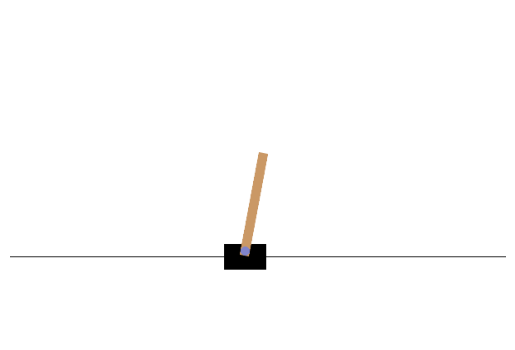

In [ ]:
from matplotlib import pyplot as plt

state, info = env.reset()

for _ in range(50):

    frame = env.render()

    plt.imshow(frame)
    plt.axis('off')
    plt.show()

    clear_output(wait=True)

    action = env.action_space.sample()

    state, reward, terminated, truncated, info = env.step(action)

    time.sleep(0.1)

    if terminated or truncated:
        state, info = env.reset()

In [ ]:
episodes = 5

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    done = False

    while not done:

        action = env.action_space.sample()

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        state = next_state

        done = terminated or truncated

    print(f"Episode {episode+1} Total Reward: {total_reward}")

Episode 1 Total Reward: 9.0
Episode 2 Total Reward: 20.0
Episode 3 Total Reward: 22.0
Episode 4 Total Reward: 11.0
Episode 5 Total Reward: 18.0


In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

q_table = np.zeros((env.observation_space.n, env.action_space.n))

learning_rate = 0.8
discount_factor = 0.95
episodes = 1000

for episode in range(episodes):

    state, info = env.reset()

    done = False

    while not done:

        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state

        done = terminated or truncated

print("Training Completed!")
print(q_table)

Training Completed!
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
env = gym.make("FrozenLake-v1", render_mode="ansi", is_slippery=False)

state, info = env.reset()

done = False

while not done:

    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = env.step(action)

    print(env.render())

    done = terminated or truncated

if reward == 1:
    print("Agent Reached Goal!")
else:
    print("Agent Failed!")

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
S

In [ ]:
#The agent:
#moves LEFT if pole tilts LEFT
#moves RIGHT if pole tilts RIGHT

import gymnasium as gym

env = gym.make("CartPole-v1")

episodes = 5

for episode in range(episodes):

    state, info = env.reset()

    done = False
    total_reward = 0

    while not done:

        cart_position, cart_velocity, pole_angle, pole_velocity = state

        # Simple Logic
        if pole_angle < 0:
            action = 0
        else:
            action = 1

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        state = next_state

        done = terminated or truncated

    print(f"Episode {episode+1} Reward: {total_reward}")

env.close()

Episode 1 Reward: 52.0
Episode 2 Reward: 35.0
Episode 3 Reward: 41.0
Episode 4 Reward: 49.0
Episode 5 Reward: 40.0


In [ ]:
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")

episode_rewards = []

for episode in range(50):

    state, info = env.reset()

    total_reward = 0
    done = False

    while not done:

        action = env.action_space.sample()

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        state = next_state

        done = terminated or truncated

    episode_rewards.append(total_reward)

print("Training Finished")

Training Finished


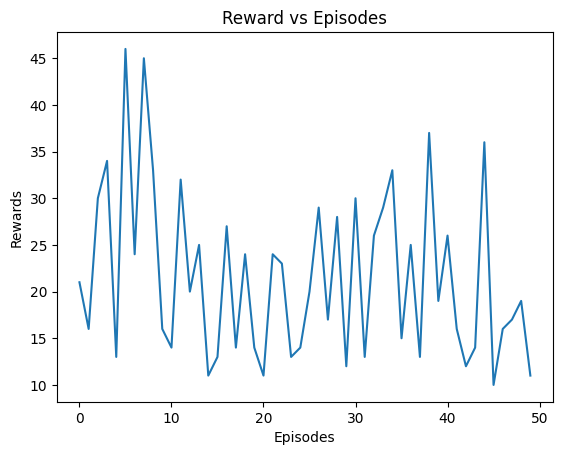

In [ ]:
plt.plot(episode_rewards)

plt.xlabel("Episodes")
plt.ylabel("Rewards")
plt.title("Reward vs Episodes")

plt.show()

In [ ]:
#Epsilon Greedy Example
import random

epsilon = 0.2

for i in range(10):

    if random.uniform(0,1) < epsilon:
        action = "Random Action (Explore)"
    else:
        action = "Best Action (Exploit)"

    print(action)

Best Action (Exploit)
Random Action (Explore)
Best Action (Exploit)
Random Action (Explore)
Best Action (Exploit)
Best Action (Exploit)
Best Action (Exploit)
Best Action (Exploit)
Best Action (Exploit)
Best Action (Exploit)


In [ ]:
# train q learnig algo
import gymnasium as gym
import numpy as np
import random

env = gym.make("FrozenLake-v1", is_slippery=False)

state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

learning_rate = 0.8
discount_factor = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 2000

for episode in range(episodes):

    state, info = env.reset()

    done = False

    while not done:

        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state

        done = terminated or truncated

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training Completed!")
print(q_table)

Training Completed!
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
env = gym.make("FrozenLake-v1", render_mode="ansi", is_slippery=False)

state, info = env.reset()

done = False

while not done:

    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = env.step(action)

    print(env.render())

    done = terminated or truncated

if reward == 1:
    print("Goal Reached!")
else:
    print("Agent Failed!")

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG

  (Left)
S